# PyTorch — Chapter 10: Project — Building a Multiclass Classification Model


## 1. Bài toán và dữ liệu

- Bộ dữ liệu **Iris** (Fisher) — 4 biến đầu vào (đo hoa, cùng đơn vị cm), 3 lớp hoa cần phân loại. Mục tiêu accuracy tham chiếu: **95–97%**.
- Nạp bằng `pandas` vì DataFrame dễ tách cột (`iloc`) và xử lý nhãn dạng chuỗi.

## 2. Mã hoá nhãn: one-hot, không phải số nguyên đơn giản

- Nếu chỉ gán số 0/1/2 cho 3 loài hoa, model có thể ngầm hiểu đây là **dữ liệu thứ tự/khoảng cách** (VD "loài 2 = loài 0 + loài 1") sẽ sai về bản chất vì nhãn là dữ liệu **nominal** chỉ là tên, không có thứ tự/khoảng cách.
- Giải pháp: **one-hot encoding** bằng `sklearn.preprocessing.OneHotEncoder` — mỗi lớp thành 1 vector nhị phân độc lập.

## 3. Model và loss

- Kiến trúc tối giản: 4 input → 8 hidden (ReLU) → 3 output. Output **không cần softmax tường minh** vì `nn.CrossEntropyLoss()` đã gộp sẵn softmax + cross-entropy bên trong.
- `CrossEntropyLoss` đo độ lệch giữa phân phối dự đoán và one-hot thật — công thức entropy chéo `H(p,q) = -Σp(x)log q(x)`.

## 4. Đánh giá và thuật ngữ dễ nhầm

- Sách gọi việc **tách train/test đơn giản** (bằng `train_test_split`) là "cross-validation" trong mục tiêu chương — nhưng nội dung thực tế **không dùng k-fold**, chỉ là 1 lần chia 70/30.
- Cải tiến quan trọng: theo dõi accuracy trên test set **sau mỗi epoch**, giữ lại bản `state_dict()` tốt nhất bằng `copy.deepcopy()` (deep copy bắt buộc, nếu không sẽ mất trọng số khi model tiếp tục cập nhật).
- `model.train()` / `model.eval()` được gọi tường minh khi chuyển giữa train và eval — thực hành chuẩn dù ở model này chưa có Dropout/BatchNorm nên chưa thấy khác biệt.


## 5. Vận dụng


**10.1** — Nạp Iris CSV bằng pandas, tách X/y

In [6]:
import pandas as pd
data = pd.read_csv("iris.csv", header=None)
X = data.iloc[:, 0:4]
y = data.iloc[:, 4:]


**10.2** — One-hot encode nhãn bằng OneHotEncoder

In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = pd.read_csv("iris.csv", header=None)
X = data.iloc[:, 0:4]
y = data.iloc[:, 4:]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(y)
print(ohe.categories_)

y = ohe.transform(y)
print(y)


[array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)]
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]


**10.3** — Định nghĩa model Multiclass (4→8→3)

In [8]:
import torch.nn as nn

class Multiclass(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 8)
        self.act = nn.ReLU()
        self.output = nn.Linear(8, 3)

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x

model = Multiclass()


**10.4** — Loss CrossEntropyLoss + optimizer Adam

In [9]:
import torch.nn as nn
import torch.optim as optim

class Multiclass(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 8)
        self.act = nn.ReLU()
        self.output = nn.Linear(8, 3)

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x

model = Multiclass()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


**10.5** — Training loop cơ bản với tqdm

In [10]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.preprocessing import OneHotEncoder

data = pd.read_csv("iris.csv", header=None)
X = data.iloc[:, 0:4]
y = data.iloc[:, 4:]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(y)
y = ohe.transform(y)

# convert pandas DataFrame (X) and numpy array (y) into PyTorch tensors
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

class Multiclass(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 8)
        self.act = nn.ReLU()
        self.output = nn.Linear(8, 3)

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x

model = Multiclass()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training parameters
n_epochs = 200
batch_size = 5
batches_per_epoch = len(X) // batch_size

for epoch in range(n_epochs):
    with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for i in bar:
            # take a batch
            start = i * batch_size
            X_batch = X[start:start+batch_size]
            y_batch = y[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()


Epoch 199: 100%|██████████| 30/30 [00:00<00:00, 424.29batch/s]


**10.6–10.7** — Tách train/test + benchmark mỗi epoch

In [11]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# read data and apply one-hot encoding
data = pd.read_csv("iris.csv", header=None)
X = data.iloc[:, 0:4]
y = data.iloc[:, 4:]
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(y)
y = ohe.transform(y)

# convert pandas DataFrame (X) and numpy array (y) into PyTorch tensors
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)


**10.8–10.10** — Code hoàn chỉnh: lưu best model + vẽ biểu đồ loss/accuracy

Epoch 0: 100%|██████████| 21/21 [00:00<00:00, 328.90batch/s, acc=0.2, loss=1.09] 


Epoch 0 validation: Cross-entropy=1.10, Accuracy=33.3%


Epoch 1: 100%|██████████| 21/21 [00:00<00:00, 330.60batch/s, acc=0.2, loss=1.04] 


Epoch 1 validation: Cross-entropy=1.04, Accuracy=33.3%


Epoch 2: 100%|██████████| 21/21 [00:00<00:00, 264.78batch/s, acc=0.4, loss=1.03] 


...

Epoch 197 validation: Cross-entropy=0.07, Accuracy=97.8%


Epoch 198: 100%|██████████| 21/21 [00:00<00:00, 276.42batch/s, acc=1, loss=0.0747] 


Epoch 198 validation: Cross-entropy=0.07, Accuracy=97.8%


Epoch 199: 100%|██████████| 21/21 [00:00<00:00, 231.05batch/s, acc=1, loss=0.0741] 


Epoch 199 validation: Cross-entropy=0.07, Accuracy=97.8%


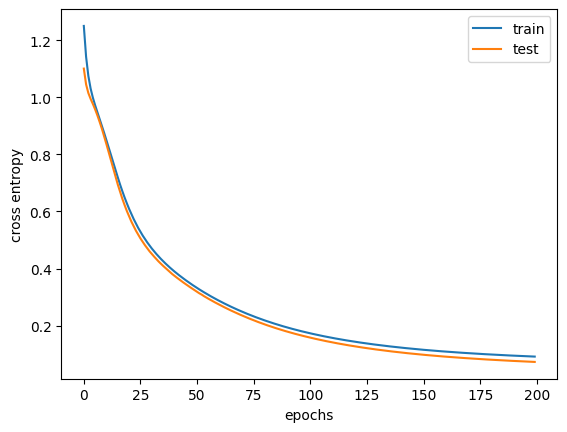

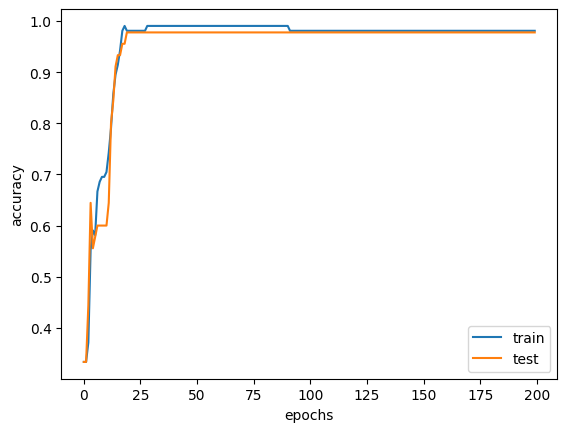

In [12]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# read data and apply one-hot encoding
data = pd.read_csv("iris.csv", header=None)
X = data.iloc[:, 0:4]
y = data.iloc[:, 4:]
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(y)
y = ohe.transform(y)

# convert pandas DataFrame (X) and numpy array (y) into PyTorch tensors
X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

class Multiclass(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(4, 8)
        self.act = nn.ReLU()
        self.output = nn.Linear(8, 3)

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x

# loss metric and optimizer
model = Multiclass()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# prepare model and training parameters
n_epochs = 200
batch_size = 5
batches_per_epoch = len(X_train) // batch_size

best_acc = - np.inf   # init to negative infinity
best_weights = None
train_loss_hist = []
train_acc_hist = []
test_loss_hist = []
test_acc_hist = []

# training loop
for epoch in range(n_epochs):
    epoch_loss = []
    epoch_acc = []
    # set model in training mode and run through each batch
    model.train()
    with tqdm.trange(batches_per_epoch, unit="batch", mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for i in bar:
            # take a batch
            start = i * batch_size
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # compute and store metrics
            acc = (torch.argmax(y_pred, 1) == torch.argmax(y_batch, 1)).float().mean()
            epoch_loss.append(float(loss))
            epoch_acc.append(float(acc))
            bar.set_postfix(
                loss=float(loss),
                acc=float(acc)
            )
    # set model in evaluation mode and run through the test set
    model.eval()
    y_pred = model(X_test)
    ce = loss_fn(y_pred, y_test)
    acc = (torch.argmax(y_pred, 1) == torch.argmax(y_test, 1)).float().mean()
    ce = float(ce)
    acc = float(acc)
    train_loss_hist.append(np.mean(epoch_loss))
    train_acc_hist.append(np.mean(epoch_acc))
    test_loss_hist.append(ce)
    test_acc_hist.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch} validation: Cross-entropy={ce:.2f}, Accuracy={acc*100:.1f}%")

# Restore best model
model.load_state_dict(best_weights)

# Plot the loss and accuracy
plt.plot(train_loss_hist, label="train")
plt.plot(test_loss_hist, label="test")
plt.xlabel("epochs")
plt.ylabel("cross entropy")
plt.legend()
plt.show()

plt.plot(train_acc_hist, label="train")
plt.plot(test_acc_hist, label="test")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()
